In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.pyplot import xlabel, ylabel
from seaborn import scatterplot

%matplotlib inline

In [78]:
data = pd.read_csv('../data/weights_heights.csv', index_col='Index')
data.head()

,Height,Weight
Index,,
1,65.78331,112.9925
2,71.51521,136.4873
3,69.39874,153.0269
4,68.21660,142.3354
5,67.78781,144.2971


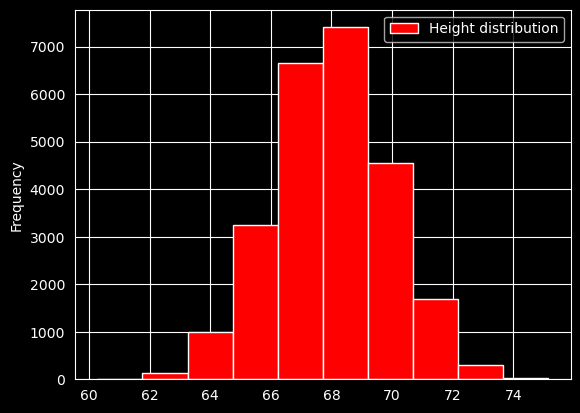

In [79]:
data.plot(y='Height', kind='hist', color='red', label='Height distribution');

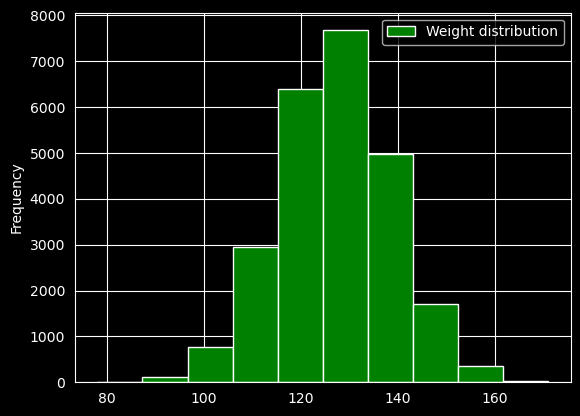

In [80]:
data.plot(y='Weight', kind='hist', color='green', label='Weight distribution');

In [81]:
def make_bmi(height_inch, weight_pound):
    METER_TO_INCH, KILO_TO_POUND = 39.37, 2.20462
    return (weight_pound / KILO_TO_POUND) / (height_inch / METER_TO_INCH) ** 2

In [82]:
data["BMI"] = data.apply(lambda row: make_bmi(row["Height"], row["Weight"]), axis=1)

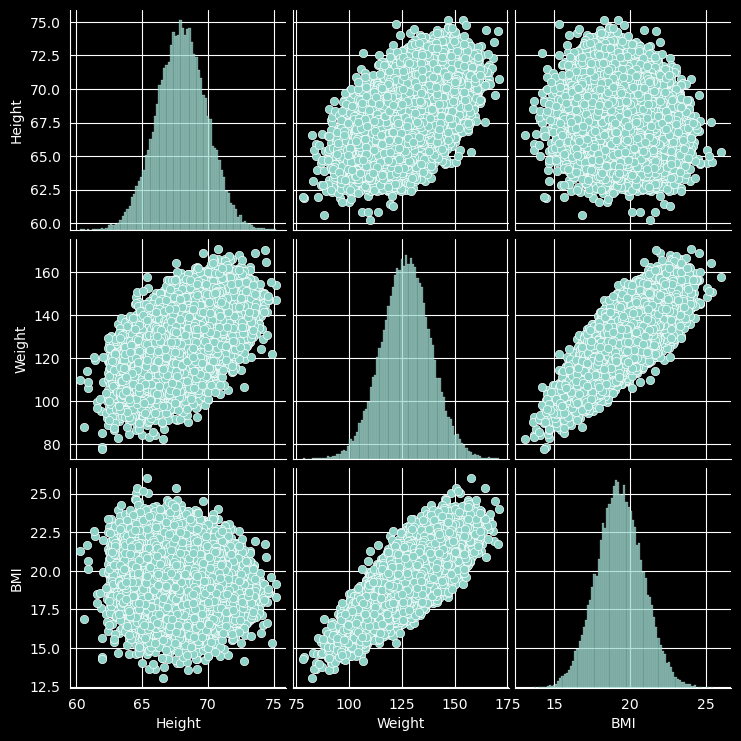

In [83]:
columns = ['Height', 'Weight', 'BMI']
sns.pairplot(data[columns]);

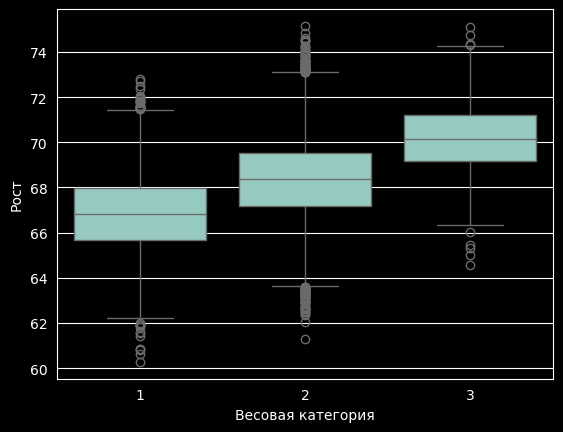

In [84]:
def weight_category(weight):
    if float(weight) < 120:
        weight_cat =  1
    elif float(weight) >= 150:
        weight_cat = 3
    else:
        weight_cat = 2

    return weight_cat

data["Weight_cat"] = data["Weight"].apply(weight_category)
sns.boxplot(x='Weight_cat', y='Height', data=data)
plt.xlabel('Весовая категория')
plt.ylabel('Рост')
plt.show()

<Axes: xlabel='Height', ylabel='Weight'>

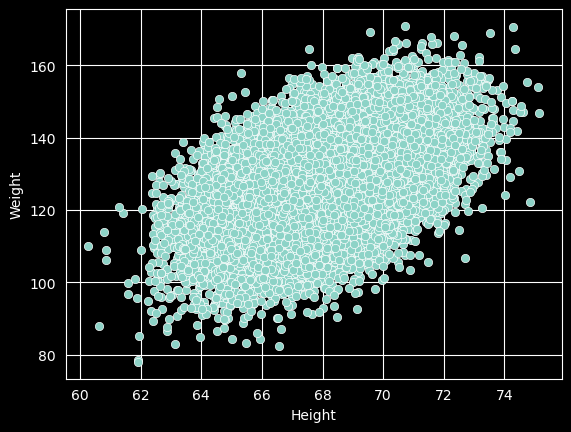

In [85]:
sns.scatterplot(x='Height', y='Weight', data=data)

In [86]:
def error(w0, w1):
    # y_i — это реальный рост (колонка Height)
    y = data["Height"]

    # x_i — это реальный вес (колонка Weight)
    x = data["Weight"]

    # Вычисляем квадраты отклонений для каждой строки и суммируем их
    return ((y - (w0 + w1 * x)) ** 2).sum()

error(60, .5)

np.float64(77797071.59057678)

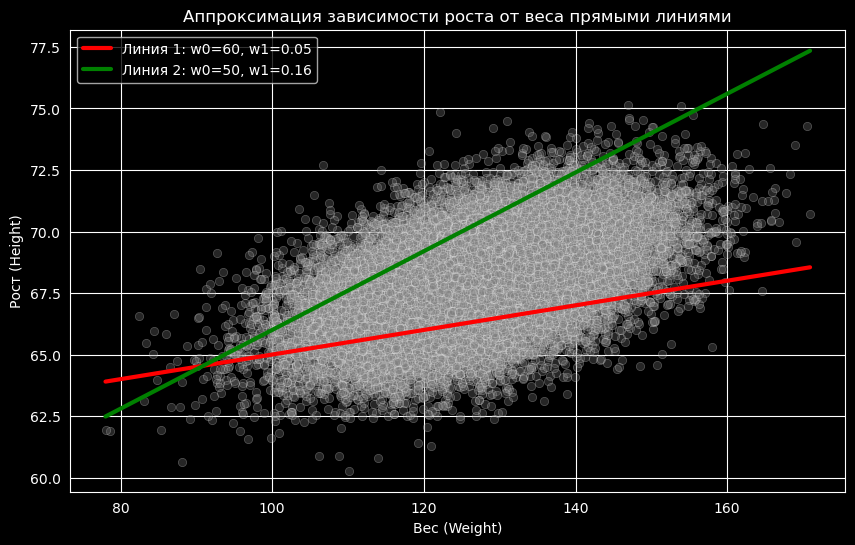

In [87]:
# alpha=0.3 делает точки полупрозрачными, чтобы линии были лучше видны
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Weight", y="Height", data=data, alpha=0.3, color="gray")

# Создаем массив значений по оси X (Вес) с помощью numpy.linspace
x_vals = np.linspace(data["Weight"].min(), data["Weight"].max(), 100)

# Считаем значения y (Рост) для первой и второй прямых
y_line1 = 60 + 0.05 * x_vals  # (w0, w1) = (60, 0.05)
y_line2 = 50 + 0.16 * x_vals  # (w0, w1) = (50, 0.16)

# Рисуем линии на графике
plt.plot(
    x_vals,
    y_line1,
    color="red",
    linewidth=3,
    label="Линия 1: w0=60, w1=0.05",
)
plt.plot(
    x_vals,
    y_line2,
    color="green",
    linewidth=3,
    label="Линия 2: w0=50, w1=0.16",
)

# Подписываем оси, добавляем название и легенду
plt.xlabel("Вес (Weight)")
plt.ylabel("Рост (Height)")
plt.title("Аппроксимация зависимости роста от веса прямыми линиями")
plt.legend()

plt.show()

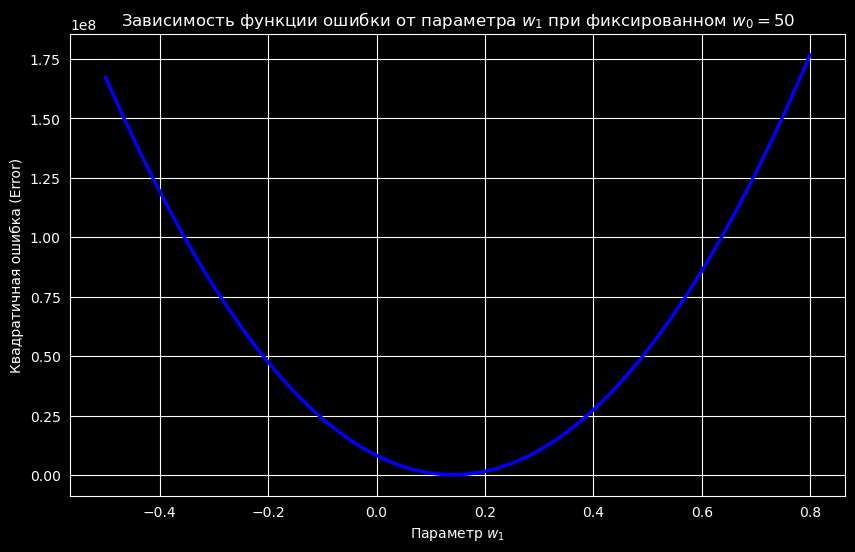

In [88]:
# Задаем фиксированное значение w0
w0 = 50

# Создаем диапазон значений для w1 с помощью np.linspace
w1_vals = np.linspace(-0.5, 0.8, 100)

# Вычисляем значение квадратичной ошибки для каждого w1
errors = [error(w0, w1) for w1 in w1_vals]

# Строим график
plt.figure(figsize=(10, 6))
plt.plot(w1_vals, errors, color="blue", linewidth=2.5)

# Подписываем оси и график
plt.xlabel("Параметр $w_1$")
plt.ylabel("Квадратичная ошибка (Error)")
plt.title("Зависимость функции ошибки от параметра $w_1$ при фиксированном $w_0 = 50$")

plt.show()

In [89]:
from scipy.optimize import minimize_scalar

# Создаем функцию одной переменной w1 при фиксированном w0 = 50
error_w1 = lambda w1: error(50, w1)

# Ищем минимум в диапазоне [-5, 5] методом 'bounded'
result = minimize_scalar(error_w1, bounds=(-5, 5), method="bounded")

# Извлекаем оптимальное значение w1
w1_opt = result.x

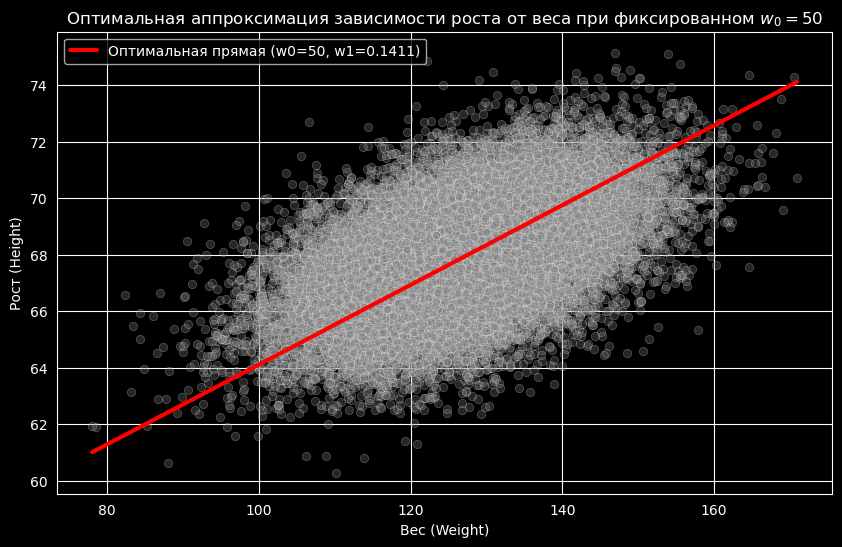

In [90]:
# Строим график рассеяния (корректные оси x - Вес, y - Рост)
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Weight", y="Height", data=data, alpha=0.3, color="gray")

# Создаем сетку точек по оси X (Вес) от минимума до максимума
x_vals = np.linspace(data["Weight"].min(), data["Weight"].max(), 100)

# Считаем Y (Рост) для оптимальной прямой: y = 50 + w1_opt * x
y_opt = 50 + w1_opt * x_vals

# Рисуем оптимальную прямую линию
plt.plot(
    x_vals,
    y_opt,
    color="red",
    linewidth=3,
    label=f"Оптимальная прямая (w0=50, w1={w1_opt:.4f})",
)

# Оформляем график
plt.xlabel("Вес (Weight)")
plt.ylabel("Рост (Height)")
plt.title("Оптимальная аппроксимация зависимости роста от веса при фиксированном $w_0 = 50$")
plt.legend()

plt.show()

In [91]:
from mpl_toolkits.mplot3d import Axes3D

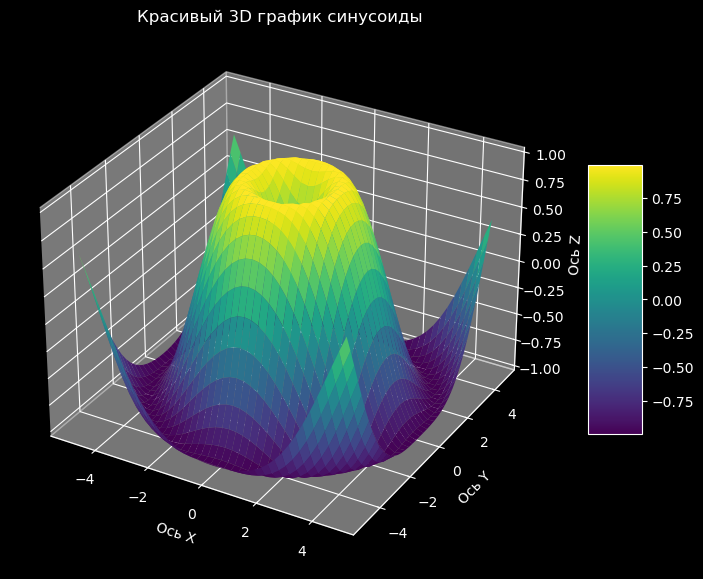

In [92]:
# Создаем фигуру
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection="3d")

# Создаем массивы NumPy с координатами точек
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
Z = np.sin(np.sqrt(X**2 + Y**2))

# Строим 3D-поверхность
surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

# Добавим цветовую шкалу (легенду) сбоку
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# Подписываем оси
ax.set_xlabel("Ось X")
ax.set_ylabel("Ось Y")
ax.set_zlabel("Ось Z")
ax.set_title("Красивый 3D график синусоиды")

plt.show()

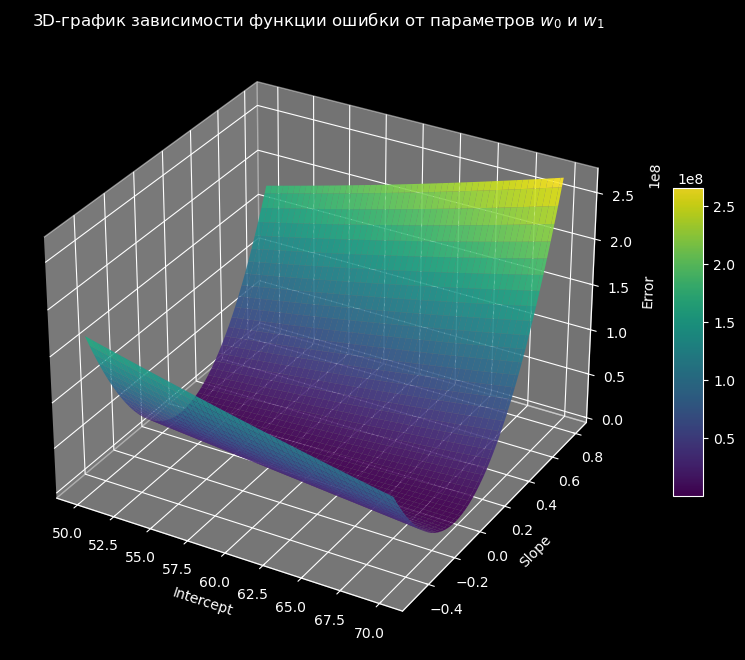

In [93]:
# Создаем диапазоны для параметров w0 (Intercept) и w1 (Slope)
w0_vals = np.linspace(50, 70, 100)
w1_vals = np.linspace(-0.5, 0.8, 100)

# Создаем сетку (meshgrid)
W0, W1 = np.meshgrid(w0_vals, w1_vals)

# Вычисляем ошибку для каждой пары (w0, w1)
# Создаем пустую матрицу нужного размера для Z координат
ERROR_GRID = np.zeros_like(W0)

# Заполняем матрицу ошибок
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        ERROR_GRID[i, j] = error(W0[i, j], W1[i, j])

# Строим 3D-график
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection="3d")

# Строим поверхность (surface) с красивой цветовой схемой
surf = ax.plot_surface(W0, W1, ERROR_GRID, cmap="viridis", edgecolor="none", alpha=0.9)

# Добавляем цветовую шкалу
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# Подписываем оси строго по заданию
ax.set_xlabel("Intercept")
ax.set_ylabel("Slope")
ax.set_zlabel("Error")

ax.set_title("3D-график зависимости функции ошибки от параметров $w_0$ и $w_1$")

plt.show()

In [94]:
from scipy.optimize import minimize

# Функция принимает один аргумент-вектор: w = [w0, w1]
def error_opt(w):
    return error(w[0], w[1])

# Начальная точка для оптимизации: (w0, w1) = (0, 0)
initial_guess = [0.0, 0.0]

# Ограничения для w0 в [-100, 100] и w1 в [-5, 5]
bounds = [(-100, 100), (-5, 5)]

# Запускаем оптимизацию методом L-BFGS-B
result_opt = minimize(error_opt, initial_guess, method="L-BFGS-B", bounds=bounds)

# Извлекаем найденные оптимальные значения
w0_opt, w1_opt = result_opt.x

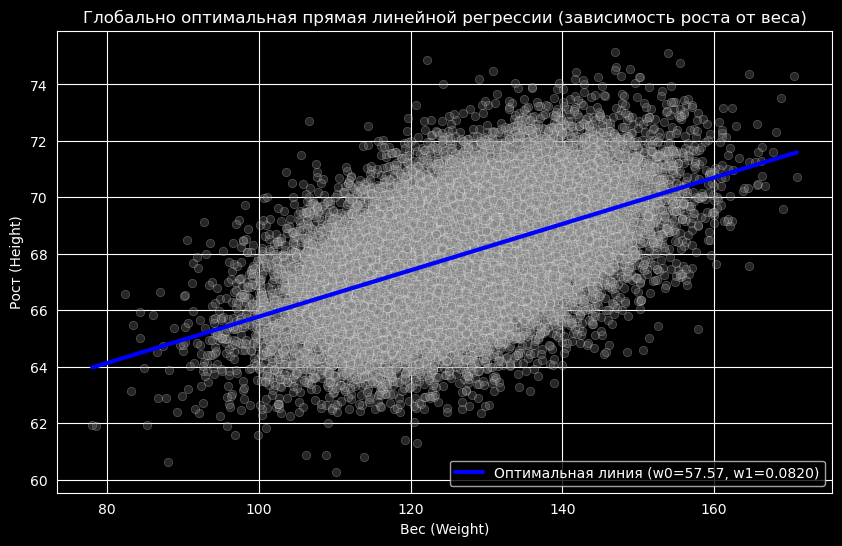

In [95]:
# График рассеяния исходных данных
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Weight", y="Height", data=data, alpha=0.3, color="gray")

# Создаем сетку точек по оси X (Вес) от минимума до максимума
x_vals = np.linspace(data["Weight"].min(), data["Weight"].max(), 100)

# Считаем Y (Рост) для глобально оптимальной прямой
y_opt = w0_opt + w1_opt * x_vals

# Рисуем глобально оптимальную прямую линию
plt.plot(
    x_vals,
    y_opt,
    color="blue",
    linewidth=3,
    label=f"Оптимальная линия (w0={w0_opt:.2f}, w1={w1_opt:.4f})",
)

# Оформляем график по условиям задачи
plt.xlabel("Вес (Weight)")
plt.ylabel("Рост (Height)")
plt.title("Глобально оптимальная прямая линейной регрессии (зависимость роста от веса)")
plt.legend()

plt.show()